# Training a ResNet50 CNN Model
**Authors:** Dickson Owuor, Raymond Cao

August 2025

## Main Goal

To train a CNN model from scratch to predict "good" and "bad" graphs. We are using a **PyTorch** training script.

In [1]:
# Installing Libraries (if not installed)
#!pip install torch torchvision

In [1]:
# Import Libraries
import torch
from PIL import Image
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from src.train_models import train_model, plot_performance, compute_mean_std, get_fc_layer

### Choose the device and Hyperparameters

In [2]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
num_epochs = 25
batch_size = 16
learning_rate = 1e-4
img_size = 224  # ResNet50 input size

# Load dataset (all data in good/ and bad/)
dataset_dir = "../train_data/manual"

Using device: cpu


In [4]:
# The images are not similar to ImageNet, they are SEM images, then it is always advised to calculate the mean and
# std of the dataset and use them to normalize the images. Path to your dataset root (which has subfolders "good" and "bad")
mean, std = compute_mean_std(dataset_dir, img_size)
print(f"Mean: {mean}")
print(f"Std: {std}")


Mean: [0.45290830731391907, 0.45292428135871887, 0.36621996760368347]
Std: [0.2247396558523178, 0.22474659979343414, 0.15336014330387115]


In [5]:
# Data transformations
transform_pipe = transforms.Compose([
    transforms.Resize((img_size, img_size)),                # Resize the image to 224 x 224 as required by most vision models
    transforms.RandomHorizontalFlip(),                      # flip the image left-right with probability 0.5 (prevents model networks from overfitting)
    transforms.RandomRotation(10),                          # rotate the image by 10 degrees with probability 0.5 (helps model to recognize the same pattern even if the image is slightly rotated)
    transforms.ColorJitter(brightness=0.1, contrast=0.1),   # randomly adjust brightness, contrast and saturation of the image (without this augmentation model might memorize training data--overfits)
    transforms.ToTensor(),      # Converts PIL/Numpy/cv2 image of range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0] -- Model networks prefer floating point tensors
    transforms.Normalize(       # Ensures all pixels are within a similar scale
        mean=mean,
        std=std
    )
])

In [6]:
# Load dataset
full_dataset = datasets.ImageFolder(dataset_dir, transform=transform_pipe)

# Train/Val split (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [9]:
# Models
# 1. ResNet50 (Residual Network)
# 2. DenseNet121 (Densely Connected Convolutional Networks)
# 3. ViT-B/16 (Vision Transformer)

# weights=None (No Pretrained Weights)
networks = {
    "resnet50": {"name": "resnet50", "model": models.resnet50(weights=None), "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []},
   "resnet50pretrained": {"name": "resnet50pretrained", "model": models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1), "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []},
    "densenet121": {"name": "densenet121", "model": models.densenet121(weights=None), "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []},
    "densenet121pretrained": {"name": "densenet121pretrained", "model": models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1), "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []},
    "vitB16pretrained": {"name": "vitB16pretrained", "model":  models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1), "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []},
}

for name, model_data in networks.items():
    print(f"{name}")
    if name.startswith("resnet50"):
        model_data["model"].fc = get_fc_layer(model_data["model"].fc.in_features)
    elif name.startswith("densenet121"):
        model_data["model"].classifier = get_fc_layer(model_data["model"].classifier.in_features)
    elif name.startswith("vitB16"):
        model_data["model"].heads.head = get_fc_layer(model_data["model"].heads.head.in_features)
    model_data["model"] = model_data["model"].to(device)
#print(model)

resnet50
resnet50pretrained
densenet121
densenet121pretrained
vitB16pretrained


In [10]:
# Choose model
sel_ntwk = networks["vitB16pretrained"]

In [11]:
# Train Model
train_model(sel_ntwk, num_epochs, learning_rate, train_loader, train_dataset, val_loader, val_dataset, device)

Epoch [1/25] Train Loss: 0.9183, Train Acc: 0.4500 -- Val Loss: 0.8946, Val Acc: 0.4615
Epoch [2/25] Train Loss: 0.7399, Train Acc: 0.5300 -- Val Loss: 0.6130, Val Acc: 0.6923
Epoch [3/25] Train Loss: 0.6167, Train Acc: 0.6100 -- Val Loss: 0.5279, Val Acc: 0.7692
Epoch [4/25] Train Loss: 0.5161, Train Acc: 0.7300 -- Val Loss: 0.5118, Val Acc: 0.6538
Epoch [5/25] Train Loss: 0.6007, Train Acc: 0.6700 -- Val Loss: 0.5005, Val Acc: 0.7308
Epoch [6/25] Train Loss: 0.5229, Train Acc: 0.7300 -- Val Loss: 0.4910, Val Acc: 0.7308
Epoch [7/25] Train Loss: 0.4978, Train Acc: 0.7300 -- Val Loss: 0.4137, Val Acc: 0.7692
Epoch [8/25] Train Loss: 0.5055, Train Acc: 0.7000 -- Val Loss: 0.4631, Val Acc: 0.7308
Epoch [9/25] Train Loss: 0.4978, Train Acc: 0.7200 -- Val Loss: 0.4125, Val Acc: 0.7692
Epoch [10/25] Train Loss: 0.4276, Train Acc: 0.8100 -- Val Loss: 0.3686, Val Acc: 0.8462
Epoch [11/25] Train Loss: 0.4098, Train Acc: 0.8100 -- Val Loss: 0.3826, Val Acc: 0.8462
Epoch [12/25] Train Loss: 0.43

### Plot Performance Results

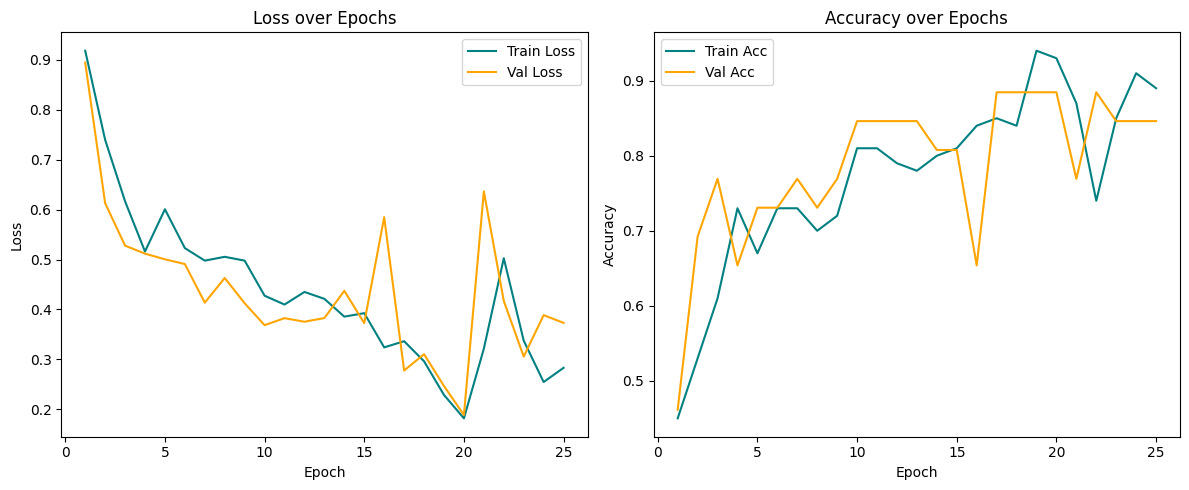

In [12]:
# Plot Results
plot_performance(sel_ntwk, num_epochs)

# Comments:
# - Best Accuracy/Loss: Pretrained DenseNet
# - Best Consistent Train/Validation Loss (no overfitting): Pretrained ViT

### Testing Model

In [23]:
# --- Load your trained model ---
# model = models.resnet50(weights=None)   # same definition as training
# model.fc = torch.nn.Sequential(
#     torch.nn.Linear(
#         in_features=model.fc.in_features,
#         out_features=1
#     ),
#     torch.nn.Sigmoid()
# )
#
# # Load the saved weights
# model.load_state_dict(torch.load("../trained_models/checkpoints/resnet50_sgt.pth", map_location="cpu"))
# model.load_state_dict(torch.load("../trained_models/checkpoints/resnet50_pretrained_sgt.pth", map_location="cpu"))
# model.eval()

In [13]:
# --- Image preprocessing ---
test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)  # same as training
])

In [52]:
# --- Load your PNG image ---
img_path = "../train_data/auto/auto_images/4.tif__run00000__0885d862.png"
img_path = "../train_data/manual/good/ANF_good3.png"
# img_path = "../train_data/manual/bad/ANF_bad3.png"
image = Image.open(img_path).convert("RGB")
image = transform_pipe(image).unsqueeze(0)  # add batch dimension

# --- Inference ---
with torch.no_grad():
    y_pred = sel_ntwk["model"](image)
    predicted_class = (y_pred >= 0.5).int()
    print(f"Predicted probabilities for {img_path}: {y_pred.item()}")

# --- Map prediction to label ---
class_names = ["bad", "good"]  # same order as your dataset class indices
pred_label = class_names[predicted_class.item()]

print(f"Predicted class for {img_path}: {pred_label}")

Predicted probabilities for ../train_data/manual/bad/ANF_bad3.png: 0.5068813562393188
Predicted class for ../train_data/manual/bad/ANF_bad3.png: good
